<a href="https://colab.research.google.com/github/kjh0718-web/portfolio/blob/main/01_machine_fault_detection_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semiconductor Equipment Trace Fault Detection Pipeline

Etch 장비 Trace 데이터에서 Step별 특징을 자동 추출하고,
정상 Reference Run을 기준으로 신규 Batch의 이상 여부를 판정한다.

## 고정 탐지 특징

1. Step 5 Pressure mean
2. Step 4 RF Load mean
3. Step 5 Pressure std
4. Step 4 Vat Valve mean
5. Step 4 He Press std

## 입력 파일

- reference_normal_trace.csv
- evaluation_batch_trace.csv

## 출력 결과

- Run별 이상 판정
- 탐지기별 Z-score
- 데이터 품질 검사
- 결과 CSV
- 결과 그래프
- 자동 분석 요약문

## 판정 기준

- Baseline: 3.0σ
- Improvement candidate: 3.3σ

In [ ]:
from pathlib import Path
from datetime import datetime
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 입력 파일 경로
REFERENCE_CSV_PATH = Path(
    "/content/reference_normal_trace.csv"
)

EVALUATION_CSV_PATH = Path(
    "/content/evaluation_batch_trace.csv"
)

# 출력 폴더
OUTPUT_DIR = Path(
    "/content/machine_fault_detection_output"
)

# 공식 Baseline
THRESHOLD_SIGMA = 3.0

print("환경 설정 완료")

환경 설정 완료


In [ ]:
# =========================================================
# 3번 셀
# 탐지기 설정 + 원클릭 분석 + 자동 보고서 함수 정의
# =========================================================


# =========================================================
# 1. 고정 탐지기 설정
# =========================================================

DETECTOR_SPECS = [
    {
        "detector": "S5_Pressure_mean",
        "step": 5,
        "variable": "Pressure",
        "feature": "mean"
    },
    {
        "detector": "S4_RF_Load_mean",
        "step": 4,
        "variable": "RF Load",
        "feature": "mean"
    },
    {
        "detector": "S5_Pressure_std",
        "step": 5,
        "variable": "Pressure",
        "feature": "std"
    },
    {
        "detector": "S4_Vat_Valve_mean",
        "step": 4,
        "variable": "Vat Valve",
        "feature": "mean"
    },
    {
        "detector": "S4_He_Press_std",
        "step": 4,
        "variable": "He Press",
        "feature": "std"
    }
]


def get_information_columns(dataframe):
    """
    데이터에 실제로 존재하면서 전체가 결측값이 아닌
    Run 정보 열만 선택한다.
    """

    candidate_columns = [
        "wafer_name",
        "experiment",
        "status",
        "fault_name"
    ]

    return [
        column
        for column in candidate_columns
        if column in dataframe.columns
        and not dataframe[column].isna().all()
    ]


# =========================================================
# 2. 입력 데이터 열 검사
# =========================================================

def validate_trace_columns(trace_df):
    """
    분석에 필요한 필수 열과 장비 변수가
    입력 CSV에 존재하는지 확인한다.
    """

    required_columns = [
        "wafer_name",
        "Time",
        "Step Number"
    ]

    required_columns.extend(
        [
            spec["variable"]
            for spec in DETECTOR_SPECS
        ]
    )

    required_columns = list(
        dict.fromkeys(required_columns)
    )

    missing_columns = [
        column
        for column in required_columns
        if column not in trace_df.columns
    ]

    if missing_columns:
        raise ValueError(
            "분석에 필요한 열이 없습니다: "
            + ", ".join(missing_columns)
        )

    print("입력 데이터 열 검사 완료")


# =========================================================
# 3. Run별 데이터 품질 검사
# =========================================================

def inspect_trace_quality(
    trace_df,
    min_rows_per_run=80,
    required_steps=(4, 5)
):
    """
    각 Run의 데이터 행 수, Step 4·5 존재 여부,
    data_quality_flag를 검사한다.
    """

    quality_records = []

    for wafer_name, wafer_data in trace_df.groupby(
        "wafer_name",
        dropna=False
    ):
        step_values = set(
            pd.to_numeric(
                wafer_data["Step Number"],
                errors="coerce"
            )
            .dropna()
            .astype(int)
            .tolist()
        )

        has_required_steps = all(
            step in step_values
            for step in required_steps
        )

        number_of_rows = len(wafer_data)

        if "data_quality_flag" in wafer_data.columns:
            row_quality_ok = (
                wafer_data["data_quality_flag"]
                .astype(str)
                .str.upper()
                .eq("OK")
                .all()
            )
        else:
            row_quality_ok = True

        valid_run = (
            number_of_rows >= min_rows_per_run
            and has_required_steps
            and row_quality_ok
        )

        record = {
            "wafer_name": wafer_name,
            "n_rows": number_of_rows,
            "step_list": sorted(step_values),
            "has_required_steps": has_required_steps,
            "row_quality_ok": row_quality_ok,
            "valid_run": valid_run
        }

        for column in [
            "experiment",
            "status",
            "fault_name"
        ]:
            if column in wafer_data.columns:
                record[column] = (
                    wafer_data[column].iloc[0]
                )

        quality_records.append(record)

    quality_summary_df = pd.DataFrame(
        quality_records
    )

    valid_wafer_names = quality_summary_df.loc[
        quality_summary_df["valid_run"],
        "wafer_name"
    ]

    valid_trace_df = trace_df[
        trace_df["wafer_name"].isin(
            valid_wafer_names
        )
    ].copy()

    print(
        "전체 Run 수:",
        trace_df["wafer_name"].nunique()
    )

    print(
        "사용 가능한 Run 수:",
        valid_trace_df["wafer_name"].nunique()
    )

    print(
        "제외된 Run 수:",
        int(
            (~quality_summary_df["valid_run"]).sum()
        )
    )

    return valid_trace_df, quality_summary_df


# =========================================================
# 4. 최종 5개 탐지 특징 추출
# =========================================================

def extract_detector_features(
    trace_df,
    detector_specs=DETECTOR_SPECS
):
    """
    각 Run에서 최종 확정된
    Step·변수·특징 조합을 자동 추출한다.
    """

    feature_results = []

    group_columns = get_information_columns(
        trace_df
    )

    if "wafer_name" not in group_columns:
        raise ValueError(
            "wafer_name 열을 사용할 수 없습니다."
        )

    for spec in detector_specs:
        step_number = spec["step"]
        variable = spec["variable"]
        feature = spec["feature"]

        step_df = trace_df[
            pd.to_numeric(
                trace_df["Step Number"],
                errors="coerce"
            ) == step_number
        ].copy()

        if step_df.empty:
            raise ValueError(
                f"Step {step_number} 데이터가 없습니다."
            )

        grouped_data = step_df.groupby(
            group_columns,
            as_index=False,
            dropna=False
        )[variable]

        if feature == "mean":
            feature_df = grouped_data.mean()

        elif feature == "std":
            feature_df = grouped_data.std()

        else:
            raise ValueError(
                f"지원하지 않는 특징입니다: {feature}"
            )

        feature_df = feature_df.rename(
            columns={
                variable: "feature_value"
            }
        )

        feature_df["detector"] = spec["detector"]
        feature_df["step"] = step_number
        feature_df["variable"] = variable
        feature_df["feature"] = feature

        feature_results.append(feature_df)

    detector_feature_df = pd.concat(
        feature_results,
        ignore_index=True
    )

    if detector_feature_df["feature_value"].isna().any():
        print(
            "주의: 일부 Run의 특징값이 결측값입니다."
        )

    return detector_feature_df


# =========================================================
# 5. Reference Normal 기준 학습
# =========================================================

def fit_detector_baseline(
    reference_trace_df,
    detector_specs=DETECTOR_SPECS
):
    """
    정상 Reference Run으로 탐지기별
    정상 중심값과 표준편차를 계산한다.
    """

    reference_features = extract_detector_features(
        reference_trace_df,
        detector_specs
    )

    baseline_df = (
        reference_features
        .groupby(
            [
                "detector",
                "step",
                "variable",
                "feature"
            ],
            as_index=False,
            dropna=False
        )
        .agg(
            normal_center=(
                "feature_value",
                "mean"
            ),
            normal_sigma=(
                "feature_value",
                "std"
            ),
            reference_run_count=(
                "wafer_name",
                "nunique"
            )
        )
    )

    invalid_baseline = baseline_df[
        baseline_df["normal_sigma"].isna()
        | (baseline_df["normal_sigma"] <= 1e-10)
    ]

    if not invalid_baseline.empty:
        raise ValueError(
            "정상 표준편차를 계산할 수 없는 탐지기가 있습니다:\n"
            + invalid_baseline[
                [
                    "detector",
                    "normal_sigma"
                ]
            ].to_string(index=False)
        )

    baseline_df["LCL_3sigma"] = (
        baseline_df["normal_center"]
        - 3 * baseline_df["normal_sigma"]
    )

    baseline_df["UCL_3sigma"] = (
        baseline_df["normal_center"]
        + 3 * baseline_df["normal_sigma"]
    )

    print(
        "정상 기준 학습 완료:",
        len(baseline_df),
        "개 탐지기"
    )

    return baseline_df


# =========================================================
# 6. Evaluation Batch 이상 점수 계산
# =========================================================

def score_evaluation_batch(
    evaluation_trace_df,
    baseline_df,
    threshold_sigma=3.0,
    detector_specs=DETECTOR_SPECS
):
    """
    평가 대상 Run의 특징을 추출하고
    Z-score와 Alarm 여부를 계산한다.
    """

    evaluation_features = extract_detector_features(
        evaluation_trace_df,
        detector_specs
    )

    score_long_df = evaluation_features.merge(
        baseline_df[
            [
                "detector",
                "normal_center",
                "normal_sigma"
            ]
        ],
        on="detector",
        how="left",
        validate="many_to_one"
    )

    if score_long_df["normal_center"].isna().any():
        raise ValueError(
            "일부 탐지기의 정상 기준을 찾지 못했습니다."
        )

    score_long_df["zscore"] = (
        score_long_df["feature_value"]
        - score_long_df["normal_center"]
    ) / score_long_df["normal_sigma"]

    score_long_df["abs_zscore"] = (
        score_long_df["zscore"].abs()
    )

    score_long_df["alarm_flag"] = (
        score_long_df["abs_zscore"]
        > threshold_sigma
    ).astype(int)

    detector_names = [
        spec["detector"]
        for spec in detector_specs
    ]

    alarm_wide_df = (
        score_long_df
        .pivot_table(
            index="wafer_name",
            columns="detector",
            values="alarm_flag",
            aggfunc="first",
            fill_value=0
        )
        .reset_index()
    )

    alarm_wide_df.columns.name = None

    for detector_name in detector_names:
        if detector_name not in alarm_wide_df.columns:
            alarm_wide_df[detector_name] = 0

    information_columns = get_information_columns(
        score_long_df
    )

    run_information_df = (
        score_long_df[information_columns]
        .drop_duplicates(
            subset=["wafer_name"]
        )
    )

    score_wide_df = run_information_df.merge(
        alarm_wide_df,
        on="wafer_name",
        how="left"
    )

    score_wide_df["total_alarm_count"] = (
        score_wide_df[detector_names]
        .sum(axis=1)
    )

    score_wide_df["final_judgment"] = np.where(
        score_wide_df["total_alarm_count"] > 0,
        "Fault Detected",
        "Normal"
    )

    max_detector_df = (
        score_long_df
        .sort_values(
            "abs_zscore",
            ascending=False
        )
        .groupby(
            "wafer_name",
            as_index=False,
            dropna=False
        )
        .first()[
            [
                "wafer_name",
                "detector",
                "zscore",
                "abs_zscore"
            ]
        ]
        .rename(
            columns={
                "detector":
                    "most_sensitive_detector",
                "zscore":
                    "most_sensitive_zscore",
                "abs_zscore":
                    "maximum_abs_zscore"
            }
        )
    )

    score_wide_df = score_wide_df.merge(
        max_detector_df,
        on="wafer_name",
        how="left"
    )

    return score_wide_df, score_long_df


# =========================================================
# 7. DataFrame 기반 원클릭 분석
# =========================================================

def run_fault_detection_pipeline(
    reference_trace_df,
    evaluation_trace_df,
    output_dir,
    threshold_sigma=3.0
):
    """
    품질검사 → 기준 학습 → 이상 판정 →
    CSV 저장을 한 번에 수행한다.
    """

    output_dir = Path(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    validate_trace_columns(reference_trace_df)
    validate_trace_columns(evaluation_trace_df)

    reference_valid_df, reference_quality_df = (
        inspect_trace_quality(
            reference_trace_df
        )
    )

    evaluation_valid_df, evaluation_quality_df = (
        inspect_trace_quality(
            evaluation_trace_df
        )
    )

    if reference_valid_df.empty:
        raise ValueError(
            "사용 가능한 Reference Normal Run이 없습니다."
        )

    if evaluation_valid_df.empty:
        raise ValueError(
            "사용 가능한 Evaluation Run이 없습니다."
        )

    baseline_df = fit_detector_baseline(
        reference_valid_df
    )

    run_result_df, detector_detail_df = (
        score_evaluation_batch(
            evaluation_valid_df,
            baseline_df,
            threshold_sigma=threshold_sigma
        )
    )

    baseline_df.to_csv(
        output_dir / "01_detector_baseline.csv",
        index=False,
        encoding="utf-8-sig"
    )

    run_result_df.to_csv(
        output_dir / "02_run_detection_result.csv",
        index=False,
        encoding="utf-8-sig"
    )

    detector_detail_df.to_csv(
        output_dir / "03_detector_detail.csv",
        index=False,
        encoding="utf-8-sig"
    )

    reference_quality_df.to_csv(
        output_dir / "04_reference_quality_check.csv",
        index=False,
        encoding="utf-8-sig"
    )

    evaluation_quality_df.to_csv(
        output_dir / "05_evaluation_quality_check.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print()
    print("원클릭 이상 탐지 완료")
    print("Alarm 기준:", threshold_sigma, "Sigma")
    print(
        "Reference Run 수:",
        reference_valid_df["wafer_name"].nunique()
    )
    print(
        "Evaluation Run 수:",
        evaluation_valid_df["wafer_name"].nunique()
    )
    print(
        "Fault Detected 수:",
        int(
            (
                run_result_df["final_judgment"]
                == "Fault Detected"
            ).sum()
        )
    )

    return {
        "baseline": baseline_df,
        "run_result": run_result_df,
        "detector_detail": detector_detail_df,
        "reference_quality": reference_quality_df,
        "evaluation_quality": evaluation_quality_df
    }


# =========================================================
# 8. CSV 파일 기반 실행
# =========================================================

def run_pipeline_from_csv(
    reference_csv_path,
    evaluation_csv_path,
    output_dir,
    threshold_sigma=3.0
):
    """
    Reference CSV와 Evaluation CSV를 불러와
    원클릭 파이프라인을 실행한다.
    """

    reference_csv_path = Path(
        reference_csv_path
    )

    evaluation_csv_path = Path(
        evaluation_csv_path
    )

    if not reference_csv_path.exists():
        raise FileNotFoundError(
            f"Reference 파일이 없습니다: "
            f"{reference_csv_path}"
        )

    if not evaluation_csv_path.exists():
        raise FileNotFoundError(
            f"Evaluation 파일이 없습니다: "
            f"{evaluation_csv_path}"
        )

    reference_trace_df = pd.read_csv(
        reference_csv_path
    )

    evaluation_trace_df = pd.read_csv(
        evaluation_csv_path
    )

    print("CSV 입력 완료")
    print(
        "Reference 데이터 크기:",
        reference_trace_df.shape
    )
    print(
        "Evaluation 데이터 크기:",
        evaluation_trace_df.shape
    )

    if "status" in reference_trace_df.columns:
        reference_status = (
            reference_trace_df["status"]
            .astype(str)
            .str.upper()
        )

        invalid_reference = (
            reference_status != "NORMAL"
        )

        if invalid_reference.any():
            invalid_statuses = (
                reference_trace_df.loc[
                    invalid_reference,
                    "status"
                ]
                .astype(str)
                .unique()
                .tolist()
            )

            raise ValueError(
                "Reference CSV에는 정상 Run만 있어야 합니다. "
                f"확인된 Status: {invalid_statuses}"
            )

    reference_runs = set(
        reference_trace_df["wafer_name"]
        .astype(str)
    )

    evaluation_runs = set(
        evaluation_trace_df["wafer_name"]
        .astype(str)
    )

    overlapping_runs = sorted(
        reference_runs & evaluation_runs
    )

    if overlapping_runs:
        raise ValueError(
            "Reference와 Evaluation에 동일한 Run이 "
            "포함되어 있습니다: "
            + ", ".join(overlapping_runs)
        )

    return run_fault_detection_pipeline(
        reference_trace_df=reference_trace_df,
        evaluation_trace_df=evaluation_trace_df,
        output_dir=output_dir,
        threshold_sigma=threshold_sigma
    )


# =========================================================
# 9. Batch 요약표
# =========================================================

def create_batch_summary(
    run_result_df,
    reference_quality_df,
    evaluation_quality_df,
    threshold_sigma
):
    """
    Batch 전체 분석 결과를 한 행으로 요약한다.
    """

    summary_record = {
        "analysis_time": datetime.now().strftime(
            "%Y-%m-%d %H:%M:%S"
        ),
        "threshold_sigma": threshold_sigma,
        "reference_valid_runs": int(
            reference_quality_df["valid_run"].sum()
        ),
        "reference_excluded_runs": int(
            (~reference_quality_df["valid_run"]).sum()
        ),
        "evaluation_valid_runs": int(
            evaluation_quality_df["valid_run"].sum()
        ),
        "evaluation_excluded_runs": int(
            (~evaluation_quality_df["valid_run"]).sum()
        ),
        "fault_detected_runs": int(
            (
                run_result_df["final_judgment"]
                == "Fault Detected"
            ).sum()
        ),
        "normal_judgment_runs": int(
            (
                run_result_df["final_judgment"]
                == "Normal"
            ).sum()
        )
    }

    if "status" in run_result_df.columns:
        status_upper = (
            run_result_df["status"]
            .astype(str)
            .str.upper()
        )

        predicted_fault = (
            run_result_df["final_judgment"]
            == "Fault Detected"
        )

        actual_fault = status_upper == "FAULT"
        actual_normal = status_upper == "NORMAL"

        tp = int(
            (actual_fault & predicted_fault).sum()
        )

        fn = int(
            (actual_fault & ~predicted_fault).sum()
        )

        fp = int(
            (actual_normal & predicted_fault).sum()
        )

        tn = int(
            (actual_normal & ~predicted_fault).sum()
        )

        summary_record.update({
            "TP": tp,
            "FN": fn,
            "FP": fp,
            "TN": tn,
            "fault_detection_rate_pct": (
                tp / (tp + fn) * 100
                if (tp + fn) > 0
                else np.nan
            ),
            "normal_false_alarm_rate_pct": (
                fp / (fp + tn) * 100
                if (fp + tn) > 0
                else np.nan
            )
        })

    return pd.DataFrame(
        [summary_record]
    )


# =========================================================
# 10. 탐지기별 Alarm 요약
# =========================================================

def create_detector_alarm_summary(
    run_result_df,
    detector_specs=DETECTOR_SPECS
):
    """
    탐지기별 Alarm 발생 Run 수를 계산한다.
    """

    records = []

    for spec in detector_specs:
        detector_name = spec["detector"]

        alarm_count = (
            int(run_result_df[detector_name].sum())
            if detector_name in run_result_df.columns
            else 0
        )

        records.append({
            "detector": detector_name,
            "step": spec["step"],
            "variable": spec["variable"],
            "feature": spec["feature"],
            "alarm_run_count": alarm_count
        })

    return pd.DataFrame(records)


# =========================================================
# 11. 그래프 1: Run별 최대 이상 점수
# =========================================================

def save_run_anomaly_score_figure(
    run_result_df,
    figure_path,
    threshold_sigma
):
    plot_df = (
        run_result_df
        .sort_values("maximum_abs_zscore")
        .copy()
    )

    figure_height = max(
        5,
        len(plot_df) * 0.45
    )

    plt.figure(
        figsize=(10, figure_height)
    )

    bars = plt.barh(
        plot_df["wafer_name"],
        plot_df["maximum_abs_zscore"]
    )

    plt.axvline(
        threshold_sigma,
        linestyle="--",
        linewidth=1.2,
        label=f"Alarm Threshold: {threshold_sigma}σ"
    )

    for bar, value in zip(
        bars,
        plot_df["maximum_abs_zscore"]
    ):
        plt.text(
            value + 0.1,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}",
            va="center",
            fontsize=9
        )

    plt.xlabel("Maximum Absolute Z-score")
    plt.ylabel("Wafer Run")
    plt.title("Maximum Anomaly Score by Wafer Run")
    plt.legend()
    plt.grid(
        axis="x",
        alpha=0.3
    )
    plt.tight_layout()

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# =========================================================
# 12. 그래프 2: Alarm Signature Matrix
# =========================================================

def save_alarm_signature_matrix(
    run_result_df,
    figure_path,
    detector_specs=DETECTOR_SPECS
):
    detector_names = [
        spec["detector"]
        for spec in detector_specs
    ]

    matrix_df = (
        run_result_df
        .set_index("wafer_name")[detector_names]
        .copy()
    )

    figure_height = max(
        4,
        len(matrix_df) * 0.5
    )

    plt.figure(
        figsize=(10, figure_height)
    )

    image = plt.imshow(
        matrix_df.values,
        aspect="auto",
        interpolation="nearest"
    )

    plt.xticks(
        np.arange(len(detector_names)),
        detector_names,
        rotation=35,
        ha="right"
    )

    plt.yticks(
        np.arange(len(matrix_df.index)),
        matrix_df.index
    )

    for row_index in range(
        matrix_df.shape[0]
    ):
        for column_index in range(
            matrix_df.shape[1]
        ):
            plt.text(
                column_index,
                row_index,
                str(
                    int(
                        matrix_df.iloc[
                            row_index,
                            column_index
                        ]
                    )
                ),
                ha="center",
                va="center"
            )

    plt.colorbar(
        image,
        label="Alarm Flag"
    )

    plt.xlabel("Detector")
    plt.ylabel("Wafer Run")
    plt.title("Alarm Signature Matrix")
    plt.tight_layout()

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# =========================================================
# 13. 그래프 3: 탐지기별 Z-score
# =========================================================

def save_detector_response_figure(
    detector_detail_df,
    figure_path,
    threshold_sigma,
    detector_specs=DETECTOR_SPECS
):
    detector_names = [
        spec["detector"]
        for spec in detector_specs
    ]

    wafer_order = (
        detector_detail_df["wafer_name"]
        .drop_duplicates()
        .tolist()
    )

    x_position = np.arange(
        len(wafer_order)
    )

    plt.figure(
        figsize=(
            max(10, len(wafer_order) * 1.2),
            6
        )
    )

    for detector_name in detector_names:
        detector_plot_df = (
            detector_detail_df[
                detector_detail_df["detector"]
                == detector_name
            ]
            .set_index("wafer_name")
            .reindex(wafer_order)
        )

        plt.plot(
            x_position,
            detector_plot_df["abs_zscore"],
            marker="o",
            label=detector_name
        )

    plt.axhline(
        threshold_sigma,
        linestyle="--",
        linewidth=1.2,
        label=f"Threshold: {threshold_sigma}σ"
    )

    plt.xticks(
        x_position,
        wafer_order,
        rotation=45,
        ha="right"
    )

    plt.xlabel("Wafer Run")
    plt.ylabel("Absolute Z-score")
    plt.title("Detector Response by Wafer Run")
    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# =========================================================
# 14. 그래프 4: 데이터 품질검사
# =========================================================

def save_quality_summary_figure(
    reference_quality_df,
    evaluation_quality_df,
    figure_path
):
    labels = [
        "Reference\nValid",
        "Reference\nExcluded",
        "Evaluation\nValid",
        "Evaluation\nExcluded"
    ]

    values = [
        int(reference_quality_df["valid_run"].sum()),
        int((~reference_quality_df["valid_run"]).sum()),
        int(evaluation_quality_df["valid_run"].sum()),
        int((~evaluation_quality_df["valid_run"]).sum())
    ]

    plt.figure(figsize=(9, 5))

    bars = plt.bar(
        labels,
        values
    )

    for bar, value in zip(
        bars,
        values
    ):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.3,
            str(value),
            ha="center",
            va="bottom",
            fontsize=11
        )

    plt.ylabel("Number of Runs")
    plt.title("Data Quality Check Summary")
    plt.grid(
        axis="y",
        alpha=0.3
    )
    plt.tight_layout()

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# =========================================================
# 15. Markdown 분석 요약
# =========================================================

def save_analysis_summary_markdown(
    run_result_df,
    batch_summary_df,
    detector_alarm_summary_df,
    output_path,
    threshold_sigma
):
    detected_df = run_result_df[
        run_result_df["final_judgment"]
        == "Fault Detected"
    ]

    normal_df = run_result_df[
        run_result_df["final_judgment"]
        == "Normal"
    ]

    summary_row = batch_summary_df.iloc[0]

    lines = [
        "# Machine Fault Detection Analysis Summary",
        "",
        f"- Analysis time: {summary_row['analysis_time']}",
        f"- Alarm threshold: {threshold_sigma} sigma",
        (
            f"- Reference valid runs: "
            f"{int(summary_row['reference_valid_runs'])}"
        ),
        (
            f"- Evaluation valid runs: "
            f"{int(summary_row['evaluation_valid_runs'])}"
        ),
        (
            f"- Fault Detected runs: "
            f"{int(summary_row['fault_detected_runs'])}"
        ),
        (
            f"- Normal judgment runs: "
            f"{int(summary_row['normal_judgment_runs'])}"
        ),
        ""
    ]

    if (
        "fault_detection_rate_pct"
        in batch_summary_df.columns
        and not pd.isna(
            summary_row["fault_detection_rate_pct"]
        )
    ):
        lines.extend([
            "## Label-based Performance",
            "",
            (
                f"- Fault detection rate: "
                f"{summary_row['fault_detection_rate_pct']:.2f}%"
            ),
            (
                f"- Normal false alarm rate: "
                f"{summary_row['normal_false_alarm_rate_pct']:.2f}%"
            ),
            ""
        ])

    lines.extend([
        "## Detected Runs",
        ""
    ])

    if detected_df.empty:
        lines.append(
            "No run was classified as Fault Detected."
        )

    else:
        for _, row in detected_df.iterrows():
            fault_text = ""

            if (
                "fault_name" in detected_df.columns
                and pd.notna(row.get("fault_name"))
            ):
                fault_text = (
                    f" / Label: {row['fault_name']}"
                )

            lines.append(
                f"- {row['wafer_name']}"
                f"{fault_text}"
                f" / Alarm count: "
                f"{int(row['total_alarm_count'])}"
                f" / Most sensitive detector: "
                f"{row['most_sensitive_detector']}"
                f" / Maximum |Z|: "
                f"{row['maximum_abs_zscore']:.3f}"
            )

    lines.extend([
        "",
        "## Normal Judgment Runs",
        ""
    ])

    if normal_df.empty:
        lines.append(
            "No run was classified as Normal."
        )

    else:
        for _, row in normal_df.iterrows():
            lines.append(
                f"- {row['wafer_name']}"
                f" / Maximum |Z|: "
                f"{row['maximum_abs_zscore']:.3f}"
            )

    lines.extend([
        "",
        "## Detector Alarm Counts",
        ""
    ])

    for _, row in detector_alarm_summary_df.iterrows():
        lines.append(
            f"- {row['detector']}: "
            f"{int(row['alarm_run_count'])} run(s)"
        )

    lines.extend([
        "",
        "## Interpretation Guide",
        "",
        "- Pressure mean: chamber pressure level change",
        "- RF Load mean: RF matching or plasma-related change",
        "- Pressure std: chamber pressure instability",
        "- Vat Valve mean: pressure-control system response",
        "- He Press std: backside helium pressure instability",
        "",
        (
            "The detector identifies abnormal equipment behavior. "
            "It does not independently confirm the physical root cause. "
            "Alarm patterns should be used to determine "
            "inspection priority."
        )
    ])

    Path(output_path).write_text(
        "\n".join(lines),
        encoding="utf-8"
    )


# =========================================================
# 16. 최종 자동 보고서 실행 함수
# =========================================================

def run_pipeline_with_auto_report(
    reference_csv_path,
    evaluation_csv_path,
    output_dir,
    threshold_sigma=3.0
):
    """
    CSV 입력 → 품질검사 → 기준 학습 →
    이상 판정 → CSV·그래프·요약문 저장
    """

    output_dir = Path(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    figure_dir = output_dir / "figures"

    figure_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    result = run_pipeline_from_csv(
        reference_csv_path=reference_csv_path,
        evaluation_csv_path=evaluation_csv_path,
        output_dir=output_dir,
        threshold_sigma=threshold_sigma
    )

    run_result_df = result["run_result"]
    detector_detail_df = result["detector_detail"]
    reference_quality_df = result["reference_quality"]
    evaluation_quality_df = result["evaluation_quality"]

    batch_summary_df = create_batch_summary(
        run_result_df=run_result_df,
        reference_quality_df=reference_quality_df,
        evaluation_quality_df=evaluation_quality_df,
        threshold_sigma=threshold_sigma
    )

    detector_alarm_summary_df = (
        create_detector_alarm_summary(
            run_result_df
        )
    )

    batch_summary_df.to_csv(
        output_dir / "06_batch_summary.csv",
        index=False,
        encoding="utf-8-sig"
    )

    detector_alarm_summary_df.to_csv(
        output_dir / "07_detector_alarm_summary.csv",
        index=False,
        encoding="utf-8-sig"
    )

    save_run_anomaly_score_figure(
        run_result_df,
        figure_dir / "01_run_anomaly_score.png",
        threshold_sigma
    )

    save_alarm_signature_matrix(
        run_result_df,
        figure_dir / "02_alarm_signature_matrix.png"
    )

    save_detector_response_figure(
        detector_detail_df,
        figure_dir / "03_detector_response_by_run.png",
        threshold_sigma
    )

    save_quality_summary_figure(
        reference_quality_df,
        evaluation_quality_df,
        figure_dir / "04_data_quality_summary.png"
    )

    save_analysis_summary_markdown(
        run_result_df=run_result_df,
        batch_summary_df=batch_summary_df,
        detector_alarm_summary_df=(
            detector_alarm_summary_df
        ),
        output_path=(
            output_dir / "08_analysis_summary.md"
        ),
        threshold_sigma=threshold_sigma
    )

    result["batch_summary"] = batch_summary_df
    result["detector_alarm_summary"] = (
        detector_alarm_summary_df
    )

    print()
    print("자동 보고서 생성 완료")
    print("결과 저장 폴더:", output_dir)

    return result


print("최종 파이프라인 함수 정의 완료")

최종 파이프라인 함수 정의 완료


In [ ]:
from google.colab import files

uploaded = files.upload()

print("업로드된 파일:")
for file_name in uploaded:
    print("-", file_name)

Saving reference_normal_trace.csv to reference_normal_trace.csv
Saving evaluation_batch_trace.csv to evaluation_batch_trace.csv
업로드된 파일:
- reference_normal_trace.csv
- evaluation_batch_trace.csv


In [ ]:
from pathlib import Path

for path in Path("/content").glob("*.csv"):
    print(path.name)

reference_normal_trace.csv
evaluation_batch_trace.csv


CSV 입력 완료
Reference 데이터 크기: (3638, 28)
Evaluation 데이터 크기: (542, 28)
입력 데이터 열 검사 완료
입력 데이터 열 검사 완료
전체 Run 수: 37
사용 가능한 Run 수: 36
제외된 Run 수: 1
전체 Run 수: 6
사용 가능한 Run 수: 5
제외된 Run 수: 1
정상 기준 학습 완료: 5 개 탐지기

원클릭 이상 탐지 완료
Alarm 기준: 3.0 Sigma
Reference Run 수: 36
Evaluation Run 수: 5
Fault Detected 수: 4


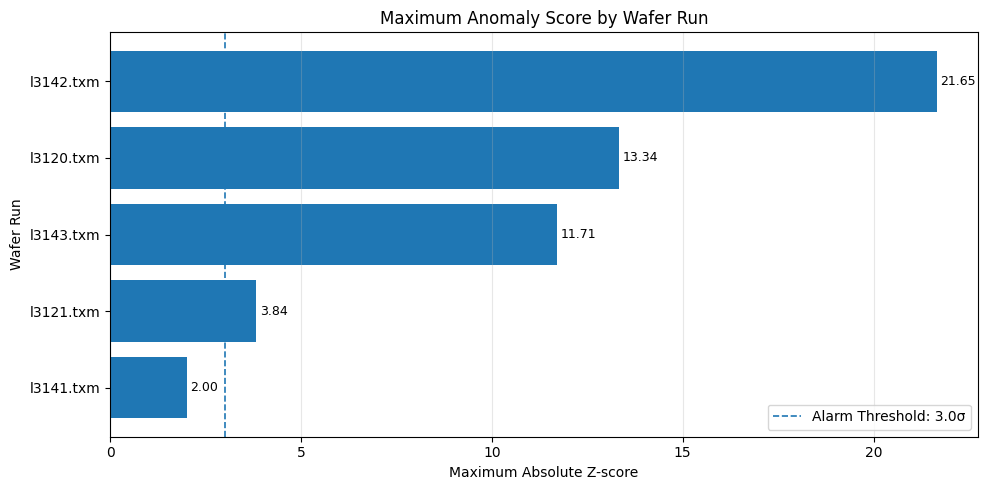

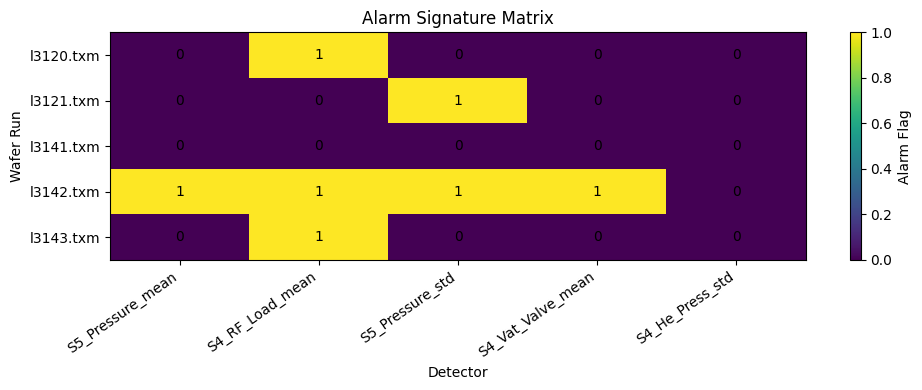

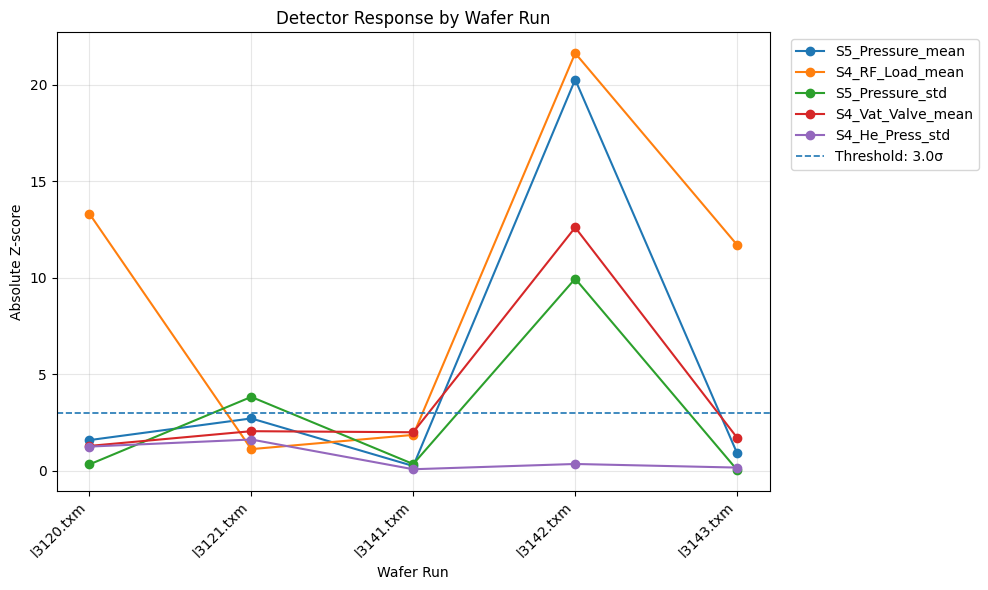

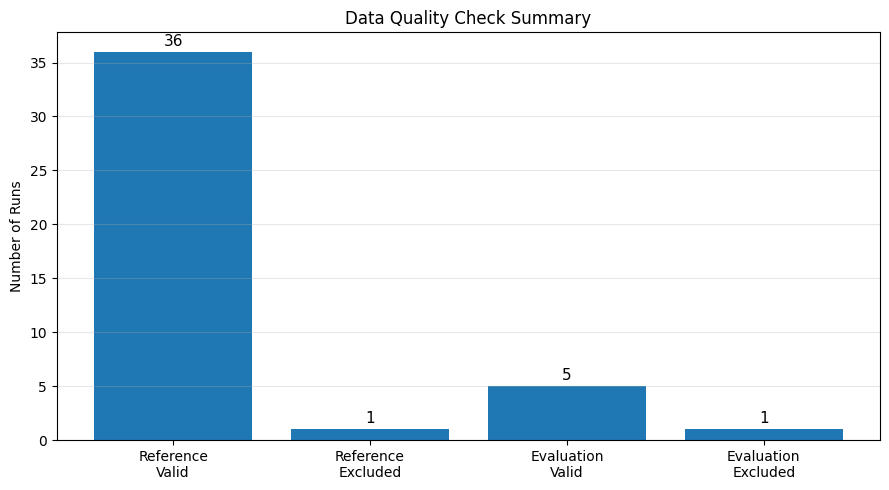


자동 보고서 생성 완료
결과 저장 폴더: /content/machine_fault_detection_output

최종 Run별 판정 결과


,wafer_name,status,fault_name,total_alarm_count,final_judgment,most_sensitive_detector,maximum_abs_zscore
3,l3142.txm,Fault,Pr +2,4,Fault Detected,S4_RF_Load_mean,21.647540
0,l3120.txm,Fault,TCP +30,1,Fault Detected,S4_RF_Load_mean,13.337795
4,l3143.txm,Fault,TCP -20,1,Fault Detected,S4_RF_Load_mean,11.709357
1,l3121.txm,Fault,Cl2 +5,1,Fault Detected,S5_Pressure_std,3.835945
2,l3141.txm,Fault,BCl3 -5,0,Normal,S4_Vat_Valve_mean,2.004181



Batch 분석 요약


,analysis_time,threshold_sigma,reference_valid_runs,reference_excluded_runs,evaluation_valid_runs,evaluation_excluded_runs,fault_detected_runs,normal_judgment_runs,TP,FN,FP,TN,fault_detection_rate_pct,normal_false_alarm_rate_pct
0,2026-07-31 07:50:42,3.0,36,1,5,1,4,1,4,1,0,0,80.0,NaN


In [ ]:
analysis_result = run_pipeline_with_auto_report(
    reference_csv_path=REFERENCE_CSV_PATH,
    evaluation_csv_path=EVALUATION_CSV_PATH,
    output_dir=OUTPUT_DIR,
    threshold_sigma=THRESHOLD_SIGMA
)

print("\n최종 Run별 판정 결과")

result_columns = [
    column
    for column in [
        "wafer_name",
        "status",
        "fault_name",
        "total_alarm_count",
        "final_judgment",
        "most_sensitive_detector",
        "maximum_abs_zscore"
    ]
    if column in analysis_result["run_result"].columns
]

display(
    analysis_result["run_result"][
        result_columns
    ].sort_values(
        "maximum_abs_zscore",
        ascending=False
    )
)

print("\nBatch 분석 요약")

display(
    analysis_result["batch_summary"].round(2)
)

In [ ]:
from pathlib import Path
import shutil
from google.colab import files

# 분석 결과 폴더
output_dir = Path(
    "/content/machine_fault_detection_output"
)

if not output_dir.exists():
    raise FileNotFoundError(
        "분석 결과 폴더가 없습니다. "
        "5번 셀을 먼저 정상 실행해 주세요."
    )

# ZIP 파일 생성
zip_base_path = Path(
    "/content/machine_fault_detection_output"
)

zip_file_path = Path(
    str(zip_base_path) + ".zip"
)

# 기존 ZIP 파일이 있으면 삭제
if zip_file_path.exists():
    zip_file_path.unlink()

created_zip_path = shutil.make_archive(
    base_name=str(zip_base_path),
    format="zip",
    root_dir=output_dir
)

print("ZIP 파일 생성 완료")
print("저장 경로:", created_zip_path)

# 컴퓨터로 다운로드
files.download(created_zip_path)

ZIP 파일 생성 완료
저장 경로: /content/machine_fault_detection_output.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>